In [ ]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
# set HF_HOME to a path with sufficient disk space
os.environ["HF_HOME"] = "/voyager-data/luoerpai/hf_cache/"
os.environ["HF_DATASETS_CACHE"]="/voyager-data/luoerpai/hf_cache/"

os.environ["PYARROW_NUM_THREADS"] = "190"     # or set a reasonable core count manually
os.environ["OMP_NUM_THREADS"] = "190"

import json
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import sys
import matplotlib.pyplot as plt
import torch.nn.functional as F

from tqdm import tqdm
import pickle
import random
import pyarrow.parquet as pq

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sys.path.append('..')
from src.utils.tokenizer import mixMulanTokenizer
from src.model.CellTempo_VQVAE.model import VQModel
from src.utils.distribution import NegativeBinomial
from src.utils.utils_metrics import map_adata_to_reference_genes
from src.utils.utils_metrics import align_expression_to_reference, load_and_concatenate_shards, get_next_cell_velo
from src.utils.utils_metrics import group_by_step_unique_first, group_by_step_unique_last

/root/miniconda3/lib/python3.10/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [ ]:
reference_gene = pd.read_csv('../data/OS_scRNA_gene_index.18791.tsv',sep='\t')['gene_name'].values

metadata = pd.read_parquet("../data/sample_metadata.parquet")

with open('../data/size_factor.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

size_factor_dict = loaded_dict

with open('/hpc-cache-pfs/home/bianhaiyang/veloMulan/dataHub/scBaseCount_scvelo_rowcount_filtered/cell_id_mapping_dict.json', 'r') as f:
    cell_name_to_num = json.load(f)

pretrained_model_path = '/hpc-cache-pfs/home/bianhaiyang/veloMulan/outputHub/vqvae_ckpt/cvqvae_scbasecount_26c24d_512n_new/checkpoint-700000/vqmodel'

model = VQModel.from_pretrained(pretrained_model_path,cvq_distance = 'cos',cvq_anchor='probrandom')#.cuda()

In [4]:
# mode = 'train'
mode = 'test'
# table = pq.read_table(f'/voyager-data/luoerpai/scBaseCount/trajectory_cross_stage_{mode}.parquet')
table = pq.read_table(f'/voyager-data/luoerpai/scBaseCount/trajectory_{mode}.parquet')
trajectory_list = table['tokens']
len(trajectory_list)

300426

# load generated cell

In [ ]:
results = []
for i in range(1):
    results.extend(torch.load(f"/hpc-cache-pfs/home/bianhaiyang/veloMulan/outputHub/trajectory/scbasecount_traj_valid/scBasetraj_exp/gpu_{i}_results_big_2624_10000_1to10_val_final.pt"))

with open('/hpc-cache-pfs/home/bianhaiyang/veloMulan/dataHub/scBaseCount_scvelo_rowcount_filtered/mix_meta_info_vq_traj.json', 'r') as f:
    meta_info = json.load(f)

__chars = meta_info['token_set']
vocab_size = len(__chars)
tokenizer = mixMulanTokenizer(__chars)

In [ ]:
# autoregressive traj

step_num = 5

traj_list = []
gt_list = []
# prefix_num is the number of cells fed to the model
for prefix_num in range(0,step_num+1):

    size_factor = []
    cell_id = []
    exp_gen = []
    gene_names = []
    gene_ids = []
    ori_exp_curr = []
    ori_exp_next = []
    for id, point in tqdm(enumerate(results)):
        c2_start = (model.num_code+3)*prefix_num+2 #point['c2_start']
        gene_name = tokenizer.decode(point['generated_ids'][c2_start:]).split('##')

        try:
            gene_id = [int(name) for name in gene_name[:model.num_code]]
        except:
            print(gene_name[:model.num_code])
            continue
        
        gene_ids.append(gene_id)
        
        codes = model.quantize.embedding.weight[gene_id]
        quant = codes.reshape(-1)
        expr = model.decoder(quant)

        exp_gen.append(expr)
        cell_name = trajectory_list[point['idx']].as_py()[prefix_num]  # cell id at the next time step
        
        cell_id.append(cell_name)

        srx = cell_name.split('_')[0]
        tissue = metadata[metadata['srx_accession']==srx]['tissue'].values[0]    
        size_factor.append(loaded_dict[tissue])
        ori_exp_next.append(point['token_labels'])
        ori_exp_curr.append(point['expr_labels'])

    reconstruct = torch.stack(exp_gen)
    size_factor = torch.tensor(size_factor)#.cuda()
    fmap = F.softmax(reconstruct, dim=-1) * size_factor.unsqueeze(-1) #real_cell_ori.sum(1).unsqueeze(-1) # #2000
    distr = NegativeBinomial(mu=fmap, theta=torch.exp(model.theta))
    reconstruct = distr.sample_ori().detach().cpu().numpy()
    # reconstruct.shape
    traj_list.append(reconstruct)
    gt_list.append(cell_id)


2000it [00:21, 94.65it/s]
2000it [00:20, 96.33it/s]
2000it [00:20, 97.93it/s]
2000it [00:20, 99.77it/s] 
2000it [00:19, 102.35it/s]
2000it [00:18, 105.82it/s]


# load scBasetraj data

In [ ]:
scbasetraj_path = '/hpc-cache-pfs/home/bianhaiyang/veloMulan/dataHub/scBaseCount_scvelo_rowcount_filtered/scBasetraj_exp'
global_dataset = load_and_concatenate_shards(scbasetraj_path)

Loading datasets: 100%|██████████| 69/69 [00:04<00:00, 14.12it/s]


In [59]:
# load ground-truth expression values; trajectory
target_dataset = global_dataset

traj_list_gt = []
for traj_id in range(step_num+1):
    positions = [cell_name_to_num.get(x) for x in gt_list[traj_id]]

    ori_exp, ori_gene = [], []
    for id, pos in tqdm(enumerate(positions)):
        next_cell_global_id = pos
        gene_names_next_cell, expr_values_next_cell = get_next_cell_velo(next_cell_global_id, global_dataset)
        ori_gene.append(gene_names_next_cell)
        ori_exp.append(expr_values_next_cell)
    expr_aligned_ori = align_expression_to_reference(ori_gene, ori_exp, reference_gene)
    traj_list_gt.append(expr_aligned_ori)

2000it [00:06, 333.28it/s]
2000it [00:05, 336.68it/s]
2000it [00:05, 352.02it/s]
2000it [00:05, 358.20it/s]
2000it [00:05, 370.03it/s]
2000it [00:05, 378.50it/s]


In [ ]:
all_traj = np.stack(gt_list).transpose(1,0)
grouped_nonempty, steps_sorted, pos_map = group_by_step_unique_last(all_traj)
# concatenate all cells in step order
adata_step_list = []
time_step_list = []
traj_list_gt = []

for step_idx, cell_ids in zip(steps_sorted, grouped_nonempty):
    positions = [cell_name_to_num.get(x) for x in cell_ids]
    # ensure order: one sub-AnnData per step, then concat
    ori_exp, ori_gene = [], []
    for id, pos in tqdm(enumerate(positions)):
        next_cell_global_id = pos
        gene_names_next_cell, expr_values_next_cell = get_next_cell_velo(next_cell_global_id, global_dataset)
        ori_gene.append(gene_names_next_cell)
        ori_exp.append(expr_values_next_cell)
    expr_aligned_ori = align_expression_to_reference(ori_gene, ori_exp, reference_gene)
    traj_list_gt.append(expr_aligned_ori)


# analyse an entire sequence

In [33]:
traj_list_gt[0].shape, traj_list[0].shape

((1000, 18791), (1000, 18791))

In [34]:
len(traj_list),len(traj_list_gt)

(6, 6)

In [ ]:
pcc_list = []
spearman_list = []
for traj_id in range(1,5+1):
    print(f'================time step {str(traj_id)}================')
    pcc_list_step = []
    spearman_list_step = []
    for cell_id in range(traj_list[traj_id].shape[0]):
        gen_cell = traj_list[traj_id][cell_id] - traj_list[traj_id-1][cell_id]#[:,genes]# #
        real_cell = traj_list_gt[traj_id][cell_id] - traj_list_gt[traj_id-1][cell_id]#[:,genes]# #[:,genes]
        
        # compute per-cell change
        gen_cell_delta = np.abs(gen_cell)
        real_cell_delta = np.abs(real_cell)
        
        # take the top 500 genes by delta for each real cell; use the same 500 genes for generated cells
        top_index = np.argpartition(real_cell_delta, -500)[-500:]
        real_cell_delta_top = real_cell_delta[top_index]
        gen_cell_delta_top = gen_cell_delta[top_index]
        # gen_cell_delta_top = np.random.normal(loc=real_cell_delta_top.mean(), scale=real_cell_delta_top.std(), size=500)
        
        # compute PCC of delta for the top 100 genes
        pcc = np.corrcoef(gen_cell_delta_top, real_cell_delta_top)[0,1]
        pcc_list_step.append(pcc)
        # compute Spearman correlation
        spearman = scipy.stats.spearmanr(gen_cell_delta_top, real_cell_delta_top)[0]
        spearman_list_step.append(spearman)
    pcc_list.append(np.mean(pcc_list_step))
    print(f'PCC: {np.mean(pcc_list_step)}')
    spearman_list.append(np.mean(spearman_list_step))
    print(f'Spearman: {np.mean(spearman_list_step)}')

/root/miniconda3/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/root/miniconda3/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
... storing 'cell_name' as categorical
... storing 'time_step' as categorical
/root/miniconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


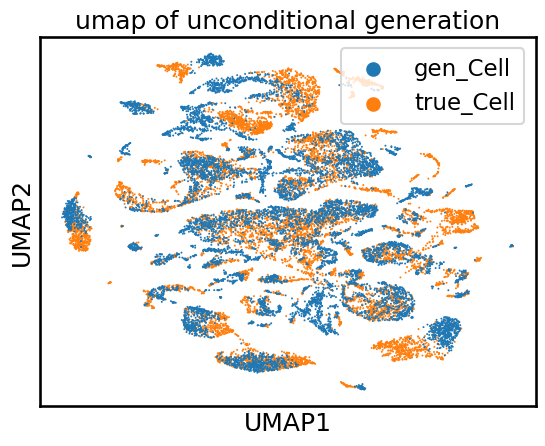

In [ ]:
# # convert back to AnnData for scanpy processing
real_cell = np.concatenate(traj_list_gt,axis=0)
gen_cell = np.concatenate(traj_list,axis=0)
adata = np.concatenate((real_cell, gen_cell),axis=0)
adata = ad.AnnData(adata, dtype=np.float32)
# adata.var_names = gene_names
adata.obs['cell_name'] = [f"true_Cell" for i in range(real_cell.shape[0])]+[f"gen_Cell" for i in range(gen_cell.shape[0])]
adata.obs['time_step'] = np.concatenate([[f'step_{i}']*traj_list[i].shape[0] for i in range(len(traj_list))]*2)
adata.obs['time_step_int'] = np.concatenate([[i]*traj_list[i].shape[0] for i in range(len(traj_list))]*2)

adata = adata[::10]
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata.raw = adata
adata = adata[:, adata.var.highly_variable]

sc.pp.scale(adata)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20)
sc.tl.umap(adata)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.pl.umap(adata, color='cell_name', size=8, title='umap of unconditional generation')
# plt.legend(loc = 'upper right')